## Initial Data Overview

- The dataset has **4,424 rows** (students) and **37 columns**.
- There are **no missing values**.
- All columns are numeric except `target`. However, many numeric columns are actually
  **categorical codes** (e.g. `marital_status`, `course`), so they need different preprocessing.

### Target distribution

| Class    | Count | Percentage |
|----------|-------|------------|
| Graduate | 2,209 | 49.9%      |
| Dropout  | 1,421 | 32.1%      |
| Enrolled |   794 | 17.9%      |

**Insight:** The classes are **imbalanced**. This means accuracy alone is not a good
metric, so we will focus on **recall and F1-score** for the Dropout class.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/data.csv", sep=";")
df.shape

(4424, 37)

In [3]:
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                          4424

In [5]:
df.isnull().sum()

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

In [6]:
df["Target"].value_counts()

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

In [7]:
df.columns.tolist()

['Marital status',
 'Application mode',
 'Application order',
 'Course',
 'Daytime/evening attendance\t',
 'Previous qualification',
 'Previous qualification (grade)',
 'Nacionality',
 "Mother's qualification",
 "Father's qualification",
 "Mother's occupation",
 "Father's occupation",
 'Admission grade',
 'Displaced',
 'Educational special needs',
 'Debtor',
 'Tuition fees up to date',
 'Gender',
 'Scholarship holder',
 'Age at enrollment',
 'International',
 'Curricular units 1st sem (credited)',
 'Curricular units 1st sem (enrolled)',
 'Curricular units 1st sem (evaluations)',
 'Curricular units 1st sem (approved)',
 'Curricular units 1st sem (grade)',
 'Curricular units 1st sem (without evaluations)',
 'Curricular units 2nd sem (credited)',
 'Curricular units 2nd sem (enrolled)',
 'Curricular units 2nd sem (evaluations)',
 'Curricular units 2nd sem (approved)',
 'Curricular units 2nd sem (grade)',
 'Curricular units 2nd sem (without evaluations)',
 'Unemployment rate',
 'Inflation r

In [9]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)
df = df.rename(columns={"nacionality": "nationality"})
df.columns.tolist()

['marital_status',
 'application_mode',
 'application_order',
 'course',
 'daytime_evening_attendance',
 'previous_qualification',
 'previous_qualification_grade',
 'nationality',
 'mother_s_qualification',
 'father_s_qualification',
 'mother_s_occupation',
 'father_s_occupation',
 'admission_grade',
 'displaced',
 'educational_special_needs',
 'debtor',
 'tuition_fees_up_to_date',
 'gender',
 'scholarship_holder',
 'age_at_enrollment',
 'international',
 'curricular_units_1st_sem_credited',
 'curricular_units_1st_sem_enrolled',
 'curricular_units_1st_sem_evaluations',
 'curricular_units_1st_sem_approved',
 'curricular_units_1st_sem_grade',
 'curricular_units_1st_sem_without_evaluations',
 'curricular_units_2nd_sem_credited',
 'curricular_units_2nd_sem_enrolled',
 'curricular_units_2nd_sem_evaluations',
 'curricular_units_2nd_sem_approved',
 'curricular_units_2nd_sem_grade',
 'curricular_units_2nd_sem_without_evaluations',
 'unemployment_rate',
 'inflation_rate',
 'gdp',
 'target']

In [10]:
df.nunique().sort_values()

daytime_evening_attendance                        2
displaced                                         2
debtor                                            2
educational_special_needs                         2
international                                     2
scholarship_holder                                2
gender                                            2
tuition_fees_up_to_date                           2
target                                            3
marital_status                                    6
application_order                                 8
inflation_rate                                    9
curricular_units_2nd_sem_without_evaluations     10
unemployment_rate                                10
gdp                                              10
curricular_units_1st_sem_without_evaluations     11
course                                           17
previous_qualification                           17
application_mode                                 18
curricular_u

In [11]:
df["marital_status"].value_counts()

marital_status
1    3919
2     379
4      91
5      25
6       6
3       4
Name: count, dtype: int64

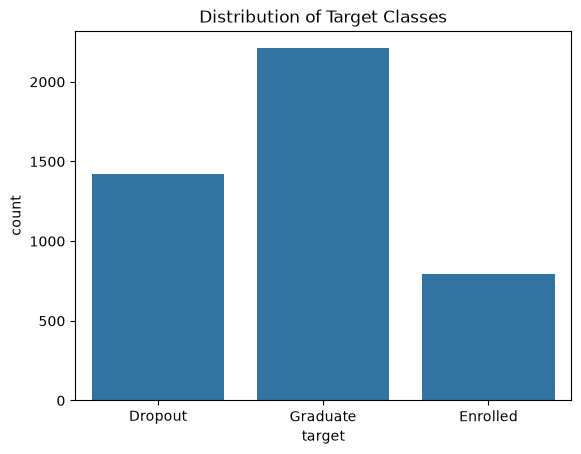

In [12]:
sns.countplot(data=df, x="target")
plt.title("Distribution of Target Classes")
plt.show()

In [14]:
df_model = df[df["target"] != "Enrolled"].copy()
df_model["dropout"] = (df_model["target"] == "Dropout").astype(int)

df_enrolled = df[df["target"] == "Enrolled"].copy()

In [15]:
print(df_model.shape, df_enrolled.shape)
print(df_model["dropout"].value_counts())

(3630, 38) (794, 37)
dropout
0    2209
1    1421
Name: count, dtype: int64


## Decision: Handling "Enrolled" Students

Students with the `Enrolled` label are still studying, so we do not know
if they will graduate or drop out. Using them in training would give the
model incorrect labels.

**Decision:**
- Train the model only on `Dropout` (1) and `Graduate` (0) students.
- Use the trained model to predict the risk for `Enrolled` students.

**Limitation:** We cannot evaluate predictions on `Enrolled` students,
because we don't know their final outcome.

In [19]:
cols = ["debtor", 
"tuition_fees_up_to_date",
"scholarship_holder",
"gender",
"displaced"]

for col in cols:
    print(df_model.groupby(col)["dropout"].mean())

debtor
0    0.344731
1    0.755448
Name: dropout, dtype: float64
tuition_fees_up_to_date
0    0.940329
1    0.306616
Name: dropout, dtype: float64
scholarship_holder
0    0.483653
1    0.138287
Name: dropout, dtype: float64
gender
0    0.302394
1    0.561249
Name: dropout, dtype: float64
displaced
0    0.459377
1    0.335675
Name: dropout, dtype: float64


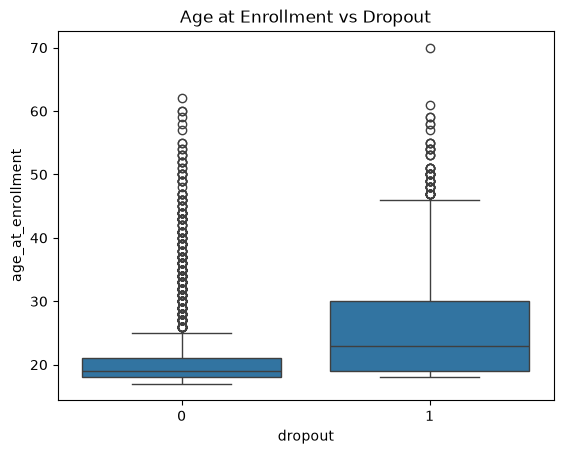

In [20]:
sns.boxplot(data=df_model, x="dropout", y="age_at_enrollment")
plt.title("Age at Enrollment vs Dropout")
plt.show()

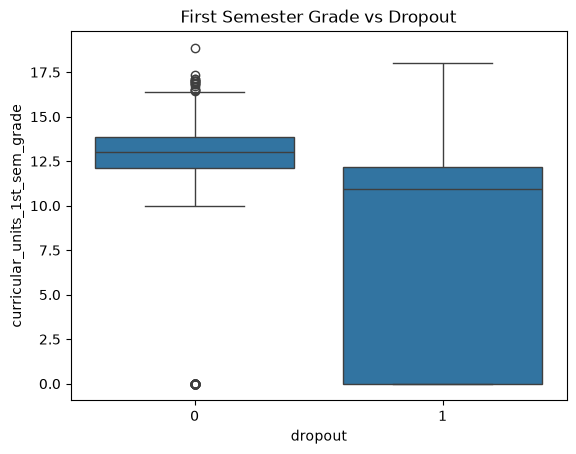

In [21]:
sns.boxplot(data=df_model, x="dropout", y="curricular_units_1st_sem_grade")
plt.title("First Semester Grade vs Dropout")
plt.show()